In [18]:
import numpy as np

class LuriaDelbruckSimulator:
    """
    Luria–Delbrück fluctuation assay simulator (single and multiple replicates).

    Single replicate:
      - Observation vector x_i: mutant counts at K time points during growth.
      - Also returns final plated mutant count (binomial downsampling).

    Multiple replicates:
      - Generates n_reps independent cultures (i.i.d.), each returning a vector.
      - Optional contamination modes to create "faulty" observations.
    """
    def __init__(self, mu, N0, G, s=0.0, K=10, plate_fraction=1.0, rng=None):
        assert 0 < mu < 1, "mu must be in (0,1)"
        assert N0 >= 1 and G >= 1 and K >= 2
        assert 0 < plate_fraction <= 1.0

        self.mu = float(mu)
        self.N0 = int(N0)
        self.G  = int(G)
        self.s  = float(s)
        self.K  = int(K)
        self.f  = float(plate_fraction)
        self.rng = np.random.default_rng() if rng is None else rng

    def _wt_trajectory(self):
        WT = np.empty(self.G + 1, dtype=float)
        WT[0] = self.N0
        for t in range(1, self.G + 1):
            WT[t] = WT[t - 1] * 2.0  # baseline doubling for wild type
        return WT

    def simulate_single(self):
        """
        Returns:
            obs_vec : (K,) int array of mutant counts over time
            final_plated_mutants : int
            meta : dict
        """
        mu, G, s, K, f, rng = self.mu, self.G, self.s, self.K, self.f, self.rng
        WT = self._wt_trajectory()

        M = np.zeros(G + 1, dtype=float)  # mutant trajectory
        growth_factor = 1.0 + s           # per-generation multiplicative for mutants

        for t in range(1, G + 1):
            divisions = WT[t - 1]
            lam = divisions * mu
            if lam > 1e8:
                new_mutants = int(np.round(rng.normal(lam, np.sqrt(lam))))
                new_mutants = max(new_mutants, 0)  # ensure non-negative
            else:
                new_mutants = rng.poisson(lam=lam)
            M[t] = M[t - 1] * growth_factor + new_mutants

        idx = np.linspace(0, G, num=K, dtype=int)
        obs_vec = np.round(M[idx]).astype(int)
        final_mutants = int(round(M[G]))
        final_plated = rng.binomial(n=max(final_mutants, 0), p=f)

        meta = {
            "WT_traj": WT,
            "M_traj": M,
            "time_idx": idx,
            "final_total_WT": WT[G],
            "final_total_M": M[G],
        }
        return obs_vec, final_plated, meta

    def simulate_replicates(
        self,
        n_reps,
        contam_rate=0.0,
        contam_mode="jackpot",   # "jackpot", "plate_loss", or "mu_shift"
        contam_strength=10.0,    # multiplier for jackpot or divisor for plate_loss
        mu_shift_factor=5.0,     # for contam_mode="mu_shift": local mu' = mu*factor
        return_plated=True,
    ):
        """
        Generate n_reps independent observation vectors (and optional plated counts).
        A fraction 'contam_rate' of replicates are made intentionally 'faulty'.

        Args:
            n_reps : int
            contam_rate : float in [0,1], expected fraction of contaminated reps
            contam_mode : str, one of {"jackpot", "plate_loss", "mu_shift"}
                - "jackpot": multiply one random time point by 'contam_strength'
                - "plate_loss": reduce final plated count by dividing by 'contam_strength'
                - "mu_shift": use a larger per-division mutation rate mu' = mu*mu_shift_factor
            contam_strength : float > 1 (used by jackpot and plate_loss)
            mu_shift_factor : float > 1 for "mu_shift"
            return_plated : include final plated counts Y

        Returns:
            X : np.ndarray, shape (n_reps, K)  -- mutant count vectors
            Y : np.ndarray, shape (n_reps,)    -- final plated counts (or None)
            meta_list : list of dicts per replicate
        """
        assert 0.0 <= contam_rate <= 1.0
        X = np.zeros((n_reps, self.K), dtype=int)
        Y = np.zeros(n_reps, dtype=int) if return_plated else None
        meta_list = []

        # Pre-draw which replicates are contaminated
        n_contam = self.rng.binomial(n=n_reps, p=contam_rate)
        contam_idx = set(self.rng.choice(n_reps, size=n_contam, replace=False))

        for i in range(n_reps):
            # Optionally adjust parameters for contaminated replicate
            if i in contam_idx and contam_mode == "mu_shift":
                # Temporarily bump mu for this replicate
                original_mu = self.mu
                self.mu = original_mu * mu_shift_factor

            x_i, y_i, meta = self.simulate_single()

            # Revert mu if shifted
            if i in contam_idx and contam_mode == "mu_shift":
                self.mu = original_mu

            # Apply contamination on the observation directly
            if i in contam_idx and contam_mode == "jackpot":
                t_bad = self.rng.integers(low=0, high=self.K)
                x_i = x_i.copy()
                x_i[t_bad] = int(round(x_i[t_bad] * contam_strength + 1))
            if i in contam_idx and contam_mode == "plate_loss":
                # keep x_i intact, but crush plated count
                if return_plated:
                    y_i = int(y_i // contam_strength)

            X[i] = x_i
            if return_plated:
                Y[i] = y_i
            meta["contaminated"] = (i in contam_idx)
            meta["contam_mode"] = contam_mode if (i in contam_idx) else None
            meta_list.append(meta)

        return X, Y, meta_list



In [119]:
# Example parameters
import torch
from sbi.utils import BoxUniform

import numpy as np

def compute_summary_statistics(data):
    """
    Compute summary statistics from simulated data.

    Parameters
    ----------
    data : np.ndarray
        Array of shape (n_obs, n_features) or (n_obs,) with simulation outputs.

    Returns
    -------
    stats : np.ndarray
        1D array of summary statistics.
    """
    data = np.asarray(data)
    if data.ndim == 1:
        data = data[:, None]

    # # Basic summaries
    # mean = data.mean()
    # var = data.var()


    # Quantiles
    quantiles = np.percentile(data, [25, 50, 75, 95]).flatten()

    # Aggregate into one vector
    # stats = np.concatenate([np.array([mean, var]), quantiles])
    # return stats
    return quantiles



def simulator(theta, N0=1e3, G=20, reps=1, contam_rate=0.0):
    mu, s = torch.tensor(theta)
    mu = 10**mu.item()  # convert log10(mu) to mu
    sim = LuriaDelbruckSimulator(mu=mu, N0=int(N0), G=int(G), s=s, K=16, plate_fraction=0.1)
    x, y, meta = sim.simulate_replicates(n_reps=reps)
    res = compute_summary_statistics(x)  # (K*(K-1)/2 + 4*K + 20,) array
    # res = np.concatenate([x, y[:, None]], axis=1)  # (K+1)*reps array
    return torch.tensor(res)  # return (K+1,) array


prior = BoxUniform(low=torch.tensor([-9, -0.2]), high=torch.tensor([-5, 0.2]))
theta = torch.tensor([[-8.0, 0.2],[-9.0,2]])  # log10(mu) = -7, s = 0.0
x = simulator(theta[0], N0=1e4, G=20, reps=1)
print(x)

tensor([ 0.0000,  0.0000,  4.5000, 64.5000], dtype=torch.float64)


/tmp/ipykernel_2205092/3759851836.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu, s = torch.tensor(theta)


In [120]:
# generate training data
N = 100_000
train_theta = prior.sample((N,))
train_x = torch.stack([simulator(train_theta[i], reps=1) for i in range(N)], dim=0)
print(train_x.shape, train_theta.shape)

/tmp/ipykernel_2205092/3759851836.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu, s = torch.tensor(theta)


torch.Size([100000, 4]) torch.Size([100000, 2])


In [121]:
# Train NPE
from sbi.inference import NPE
train_x = torch.tensor(train_x, dtype=torch.float32)

inference = NPE(prior=prior)
density_estimator = inference.append_simulations(train_theta, train_x).train()
posterior = inference.build_posterior(density_estimator)

# Save the posterior model
import pickle
with open("posterior.pkl", "wb") as f:
    pickle.dump(posterior, f)

/tmp/ipykernel_2205092/2481355693.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_x = torch.tensor(train_x, dtype=torch.float32)


 Neural network successfully converged after 127 epochs.

True theta: tensor([-7.4721,  0.0703])
Observed x_o: tensor([  0.0000,   0.0000,   6.2500, 165.2500], dtype=torch.float64)


/tmp/ipykernel_2205092/3759851836.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu, s = torch.tensor(theta)


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


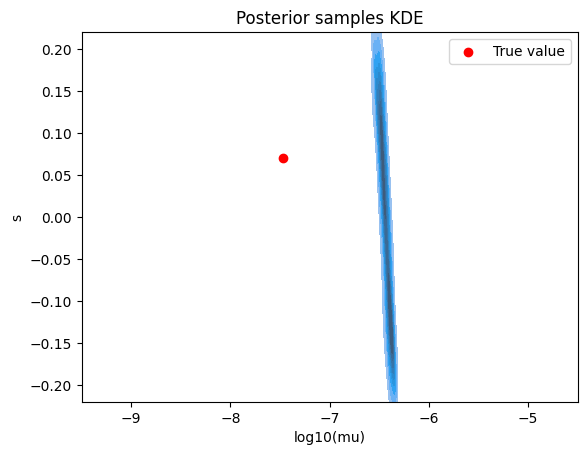

In [130]:
theta_test = prior.sample((1,))[0]  
x_o = simulator(theta_test, N0=1e4, G=20, reps=1)
print("True theta:", theta_test)
print("Observed x_o:", x_o)
samples = posterior.sample((1000,), x=x_o)
# kdeplot of samples vs true theta
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.DataFrame(samples.numpy(), columns=["log10_mu", "s"])
plt.xlim(-9.5, -4.5)
plt.ylim(-0.22, 0.22)
sns.kdeplot(data=df, x="log10_mu", y="s", fill=True)
plt.scatter(theta_test[0], theta_test[1], color='red', label='True value')
plt.xlabel("log10(mu)")
plt.ylabel("s")
plt.title("Posterior samples KDE")
plt.legend()
plt.show()